In [29]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv(r"Encoded_Cleand_Dataset.csv")


In [31]:
X = df.select_dtypes(include=['number']).copy()

In [32]:
X.drop(columns=["ID"], inplace=True)
X

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain
0,1957,1,1,58138.0,0,0,58,635,88,546,...,8,10,4,7,0,0,0,0,0,0
1,1954,1,1,46344.0,1,1,38,11,1,6,...,1,1,2,5,0,0,0,0,0,0
2,1965,1,0,71613.0,0,0,26,426,49,127,...,8,2,10,4,0,0,0,0,0,0
3,1984,1,0,26646.0,1,0,26,11,4,20,...,2,0,4,6,0,0,0,0,0,0
4,1981,4,0,58293.0,1,0,94,173,43,118,...,5,3,6,5,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2227,1967,1,0,61223.0,0,1,46,709,43,182,...,9,3,4,5,0,0,0,0,0,0
2228,1946,4,0,64014.0,2,1,56,406,0,30,...,8,2,5,7,0,0,0,1,0,0
2229,1981,1,1,56981.0,0,0,91,908,48,217,...,2,3,13,6,0,1,0,0,0,0
2230,1956,2,0,69245.0,0,1,8,428,30,214,...,6,5,10,3,0,0,0,0,0,0


# TESTING K=2 ... 10

In [33]:
k_list = []
score_list = []
label_list = []

for k in range(2, 11):
    kmeans = KMeans(
    n_clusters=k,   
    n_init= 50,  
    random_state=42    
    )

    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    label_list.append(labels)
    k_list.append(k)
    score_list.append(score)

score_df = pd.DataFrame({'K': k_list, 'Silhouette_Score': score_list})



In [34]:
score_df

,K,Silhouette_Score
0,2,0.604117
1,3,0.538140
2,4,0.529099
3,5,0.536939
4,6,0.536441
5,7,0.523400
6,8,0.517598
7,9,0.526701
8,10,0.527033


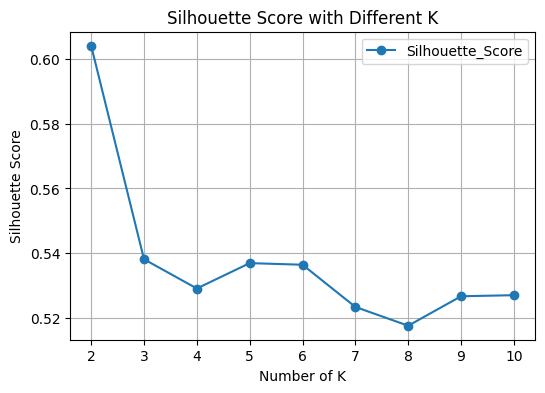

In [35]:
score_df.plot(
    x='K',
    y='Silhouette_Score',
    kind='line',
    marker='o',
    figsize=(6,4),
    title='Silhouette Score with Different K'
)

plt.xlabel('Number of K')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# Merge Cluster outcome

In [38]:
print("Group into 4: ")
final_use_label = label_list[2]
df["Cluster_group"] = final_use_label
print(df["Cluster_group"].value_counts())

print("Group into 3: ")
final_use_label = label_list[1]
df["Cluster_group"] = final_use_label
print(df["Cluster_group"].value_counts())

Group into 4: 
Cluster_group
1    688
3    672
2    468
0    404
Name: count, dtype: int64
Group into 3: 
Cluster_group
0    801
1    737
2    694
Name: count, dtype: int64


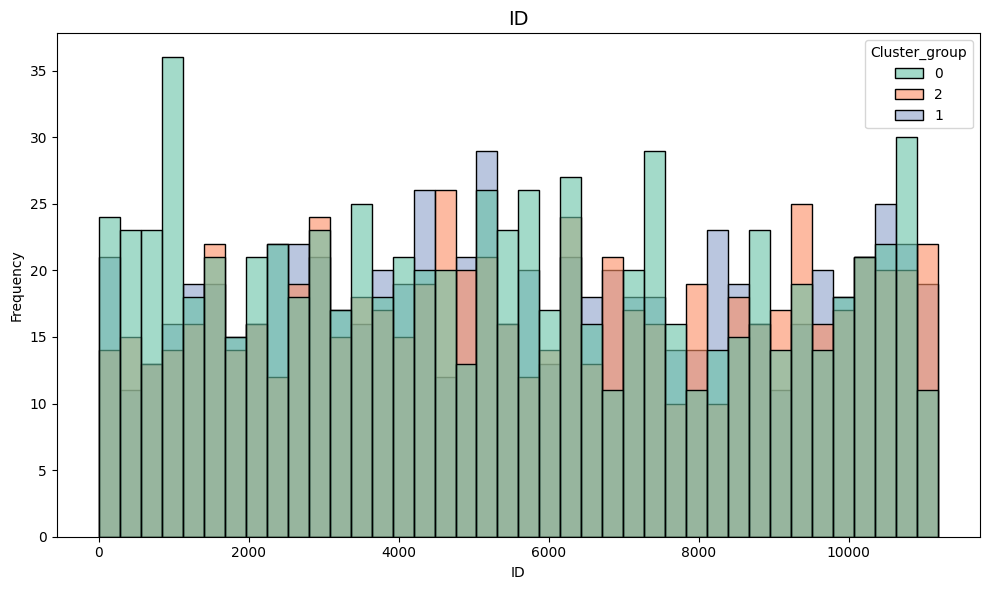

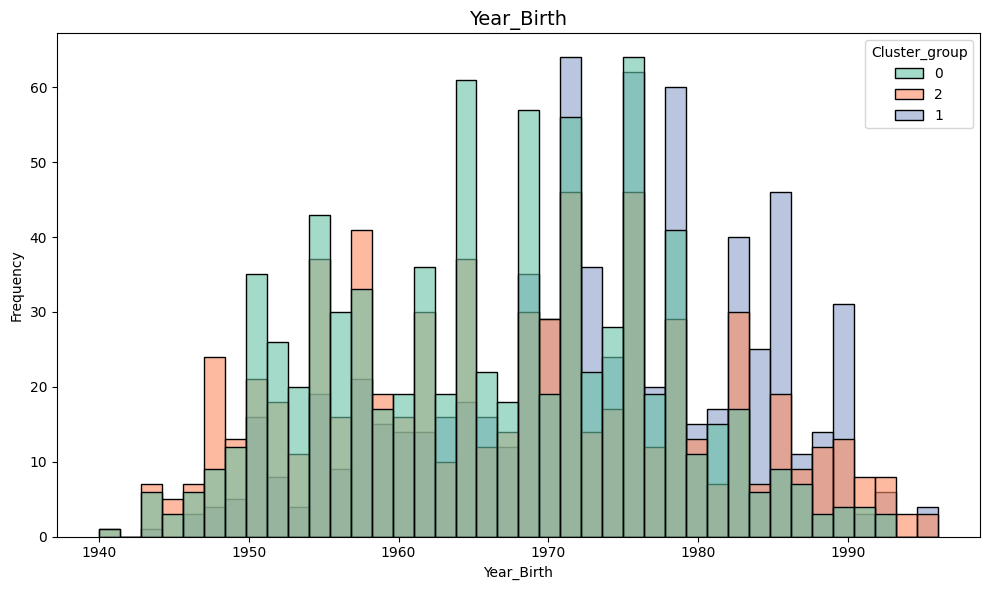

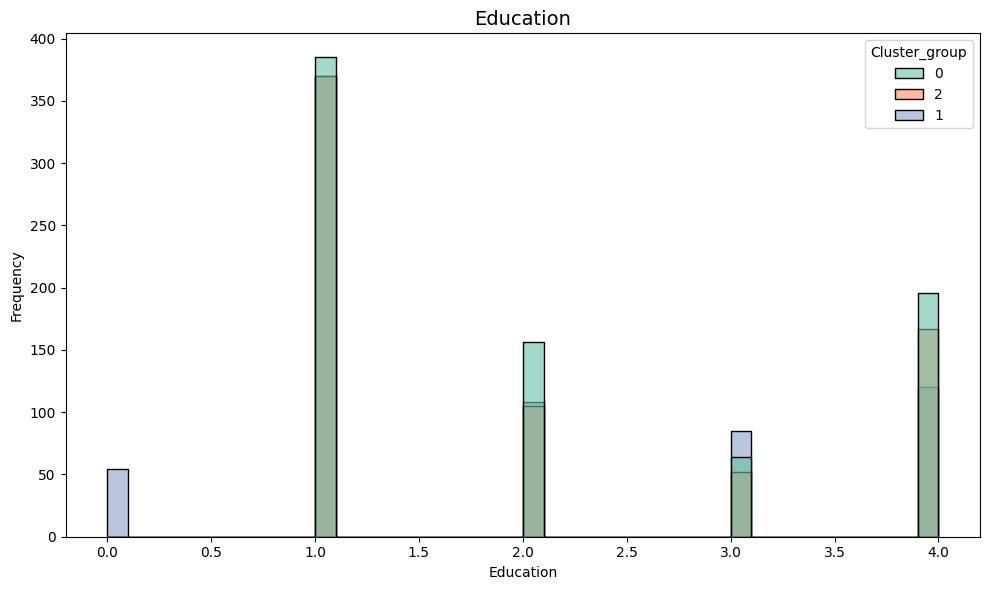

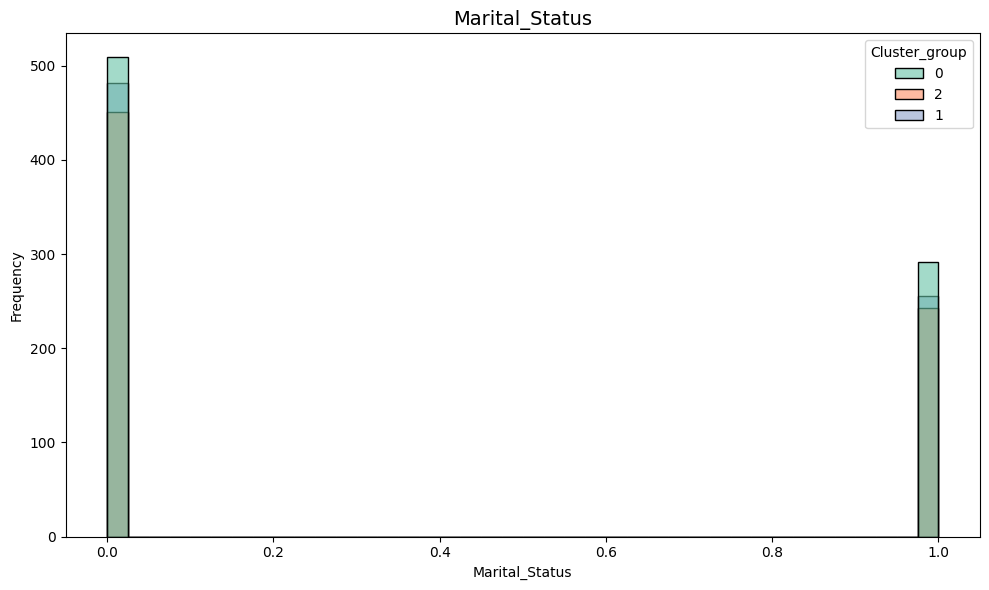

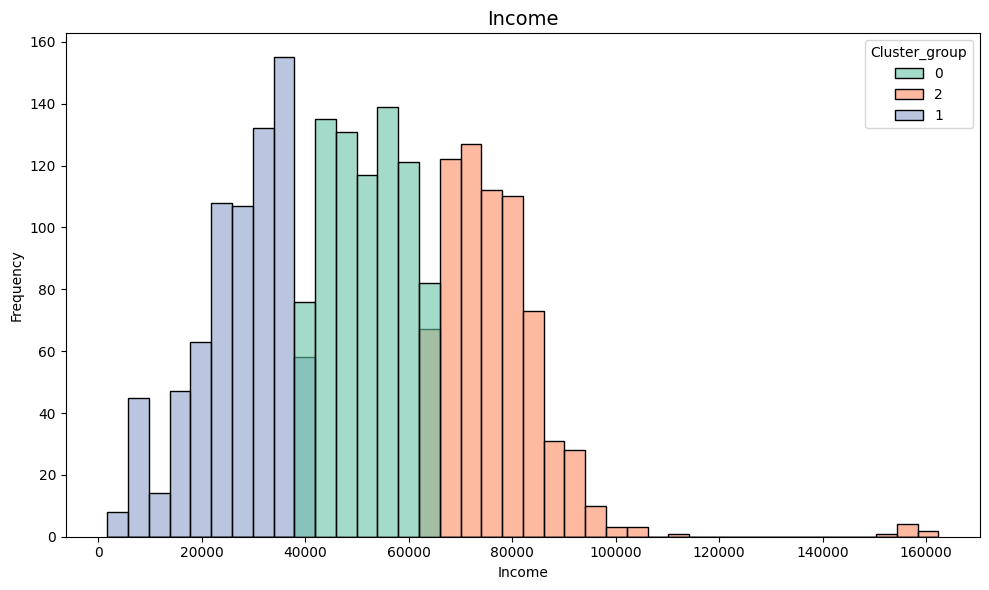

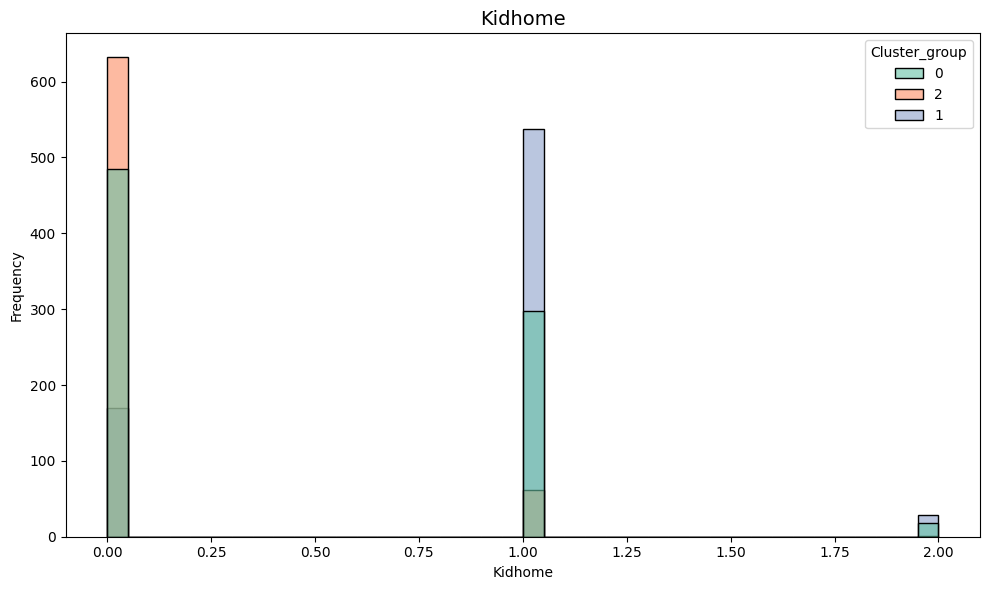

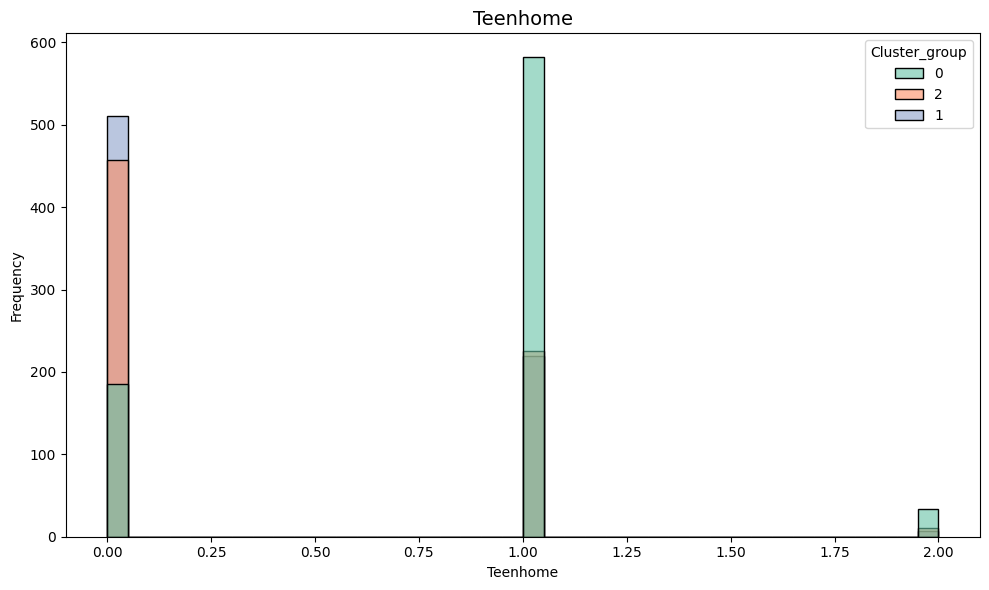

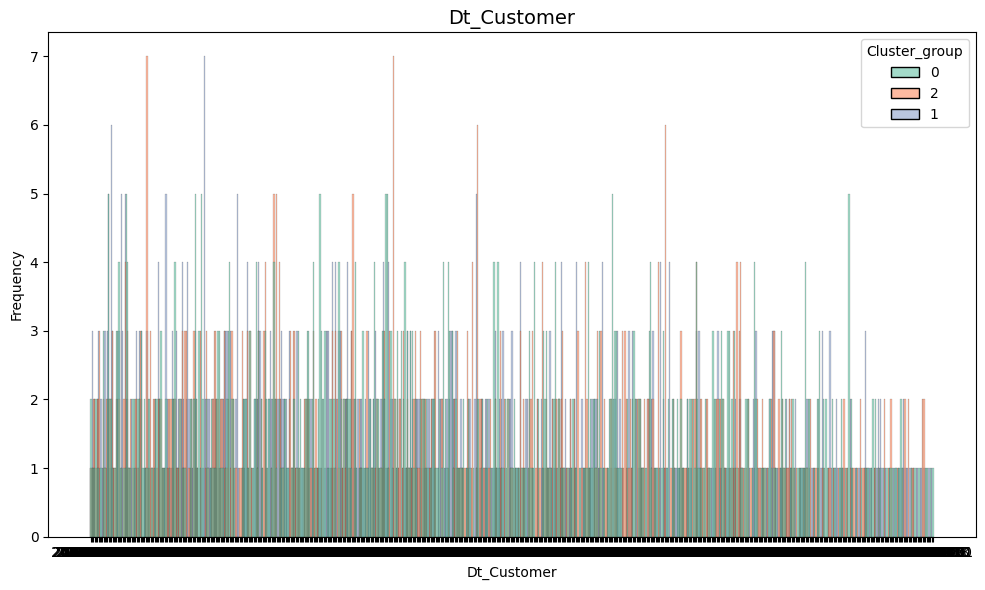

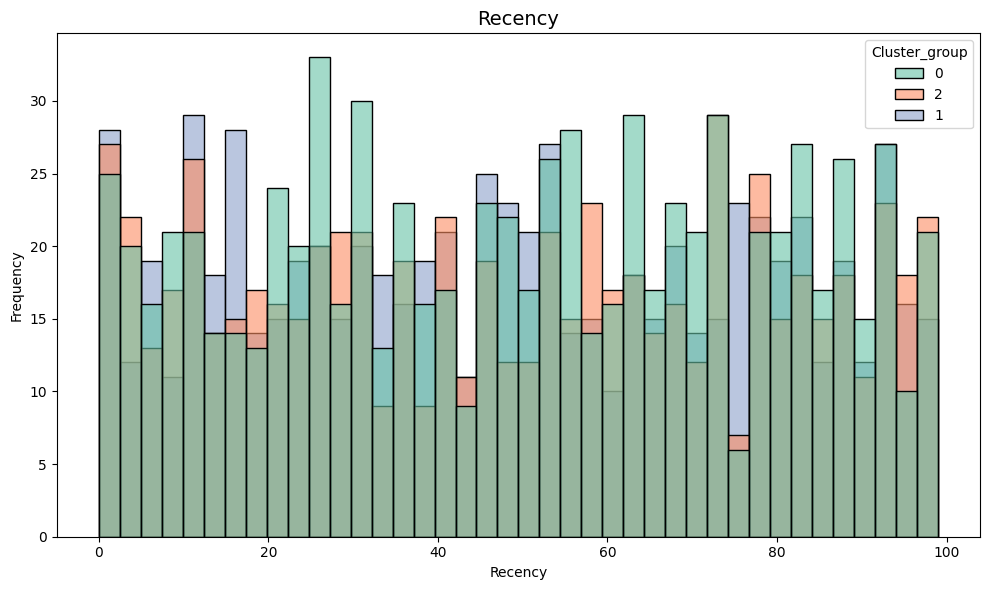

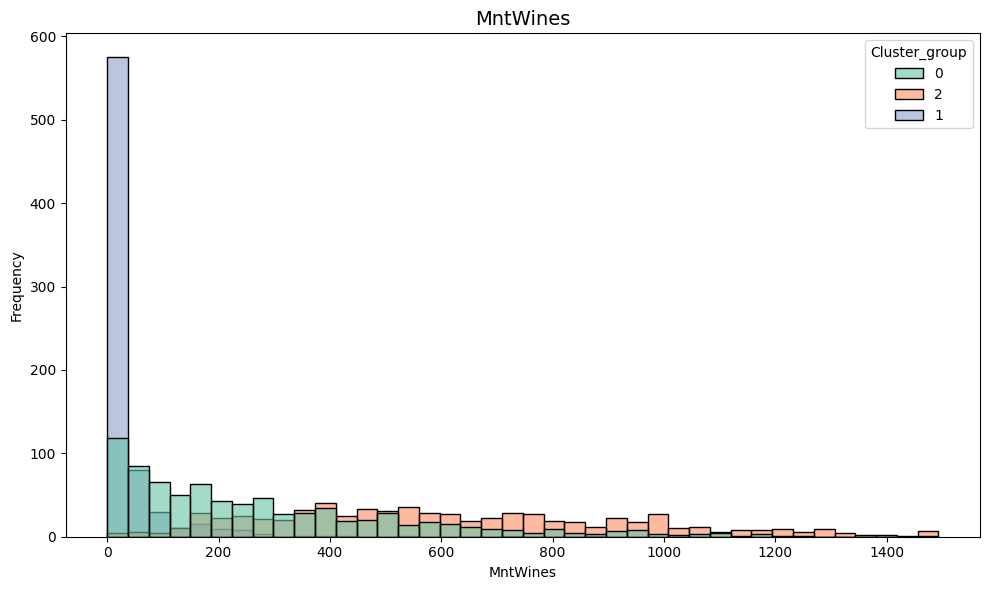

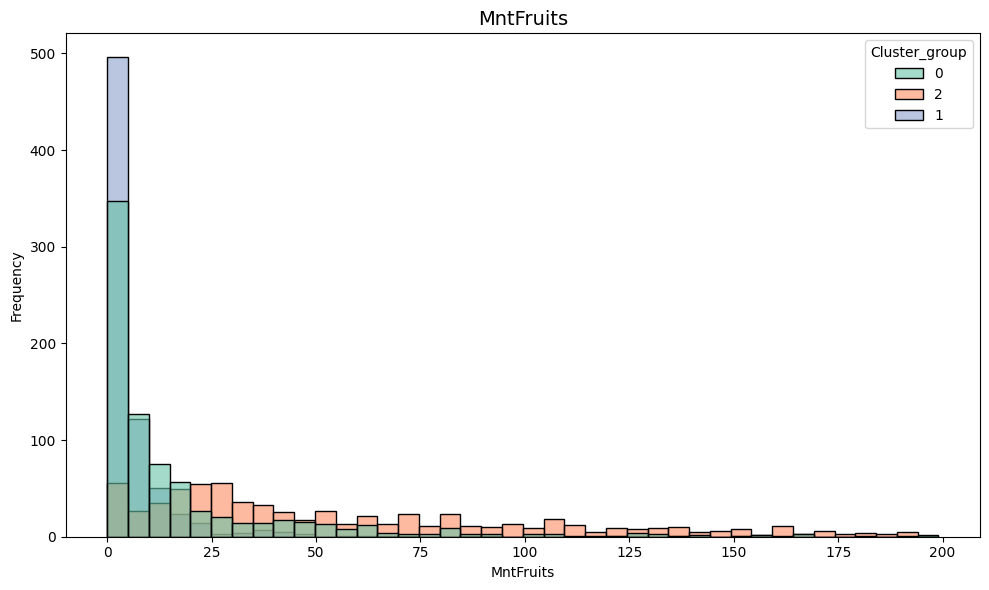

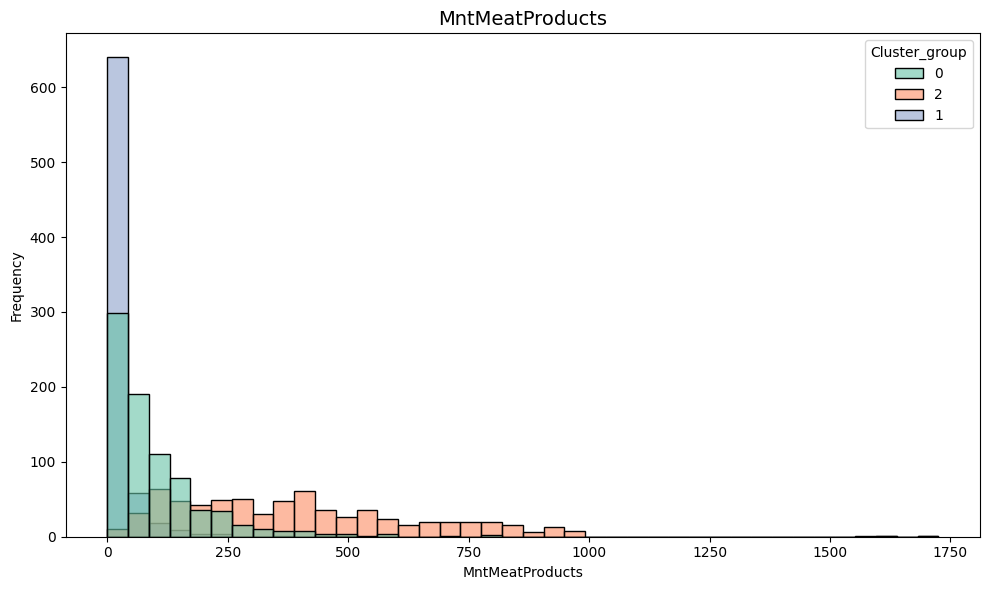

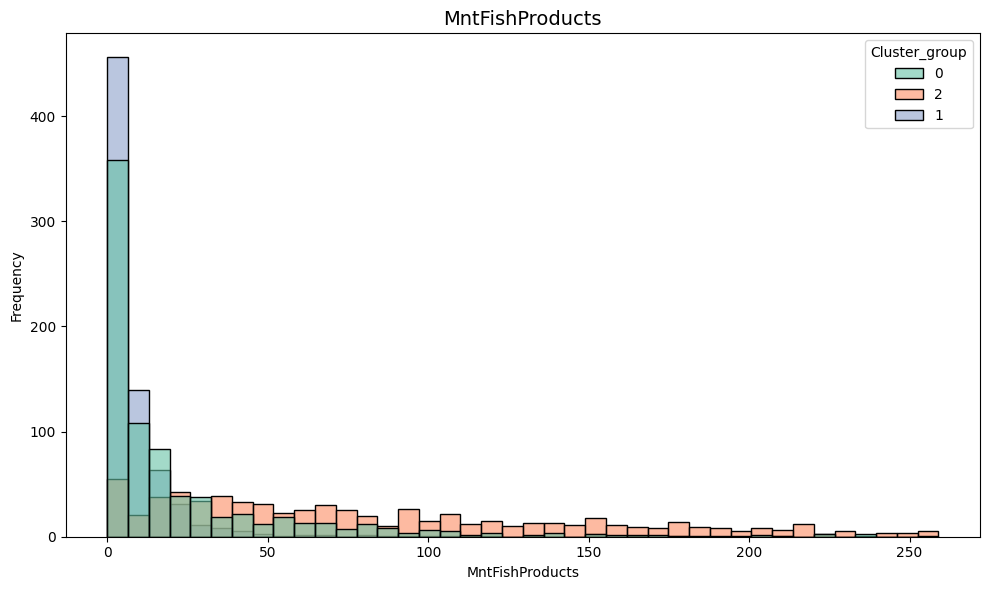

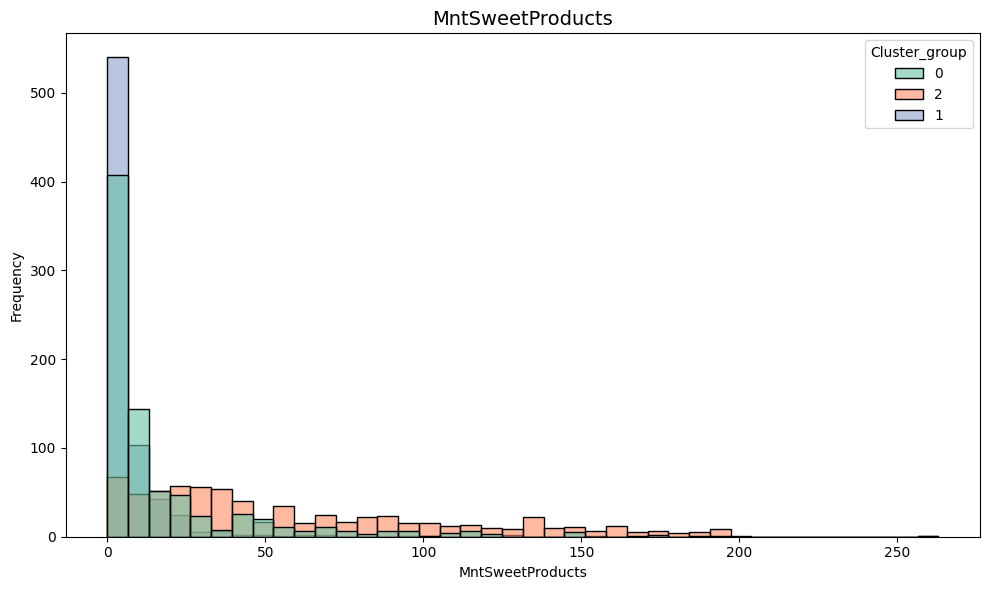

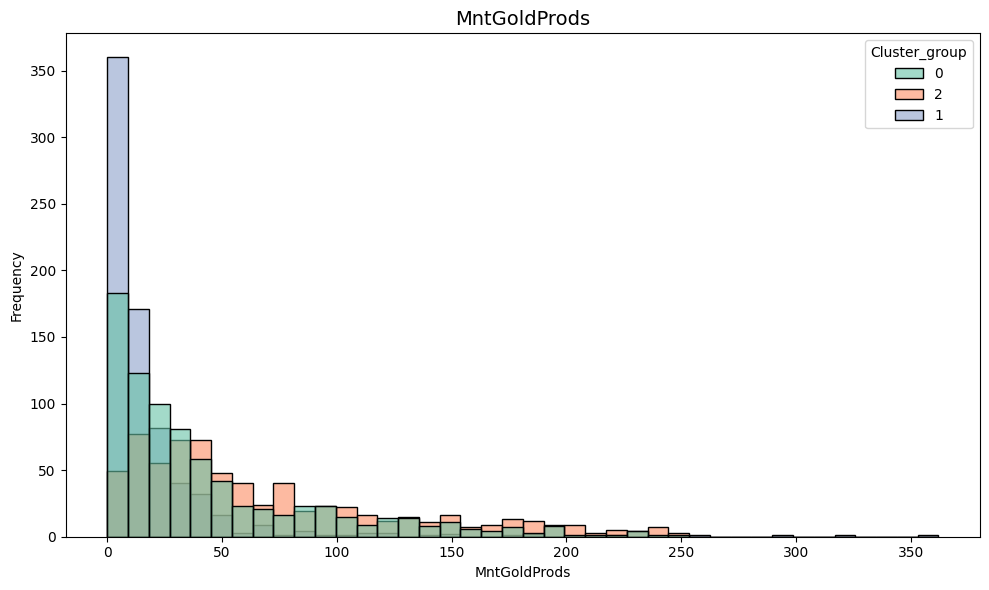

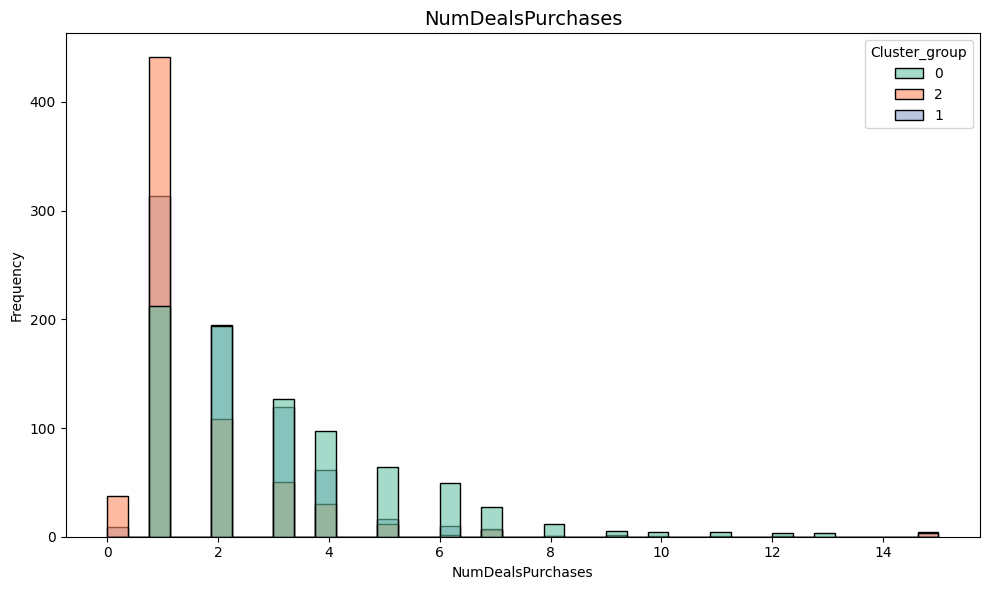

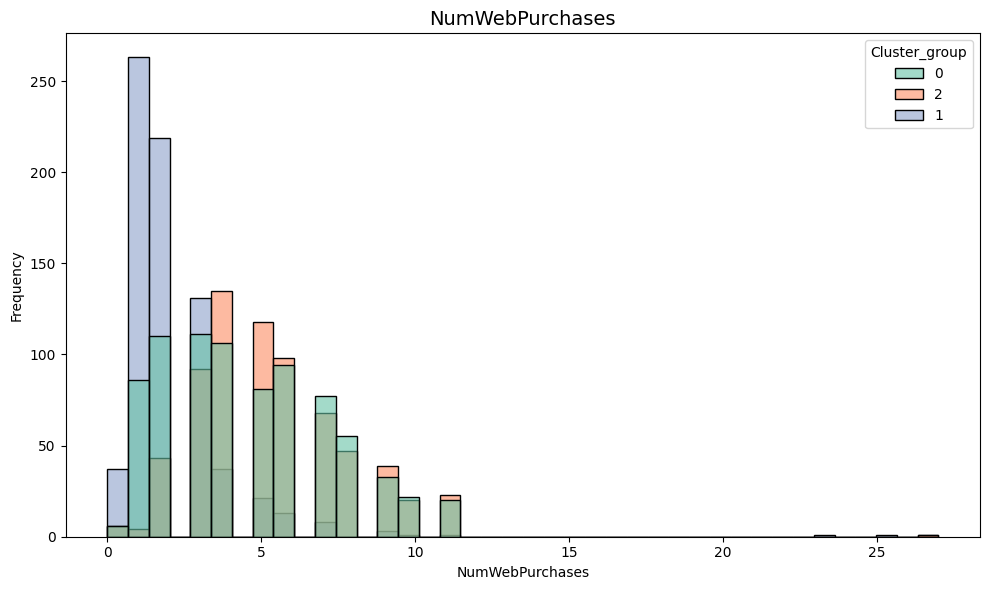

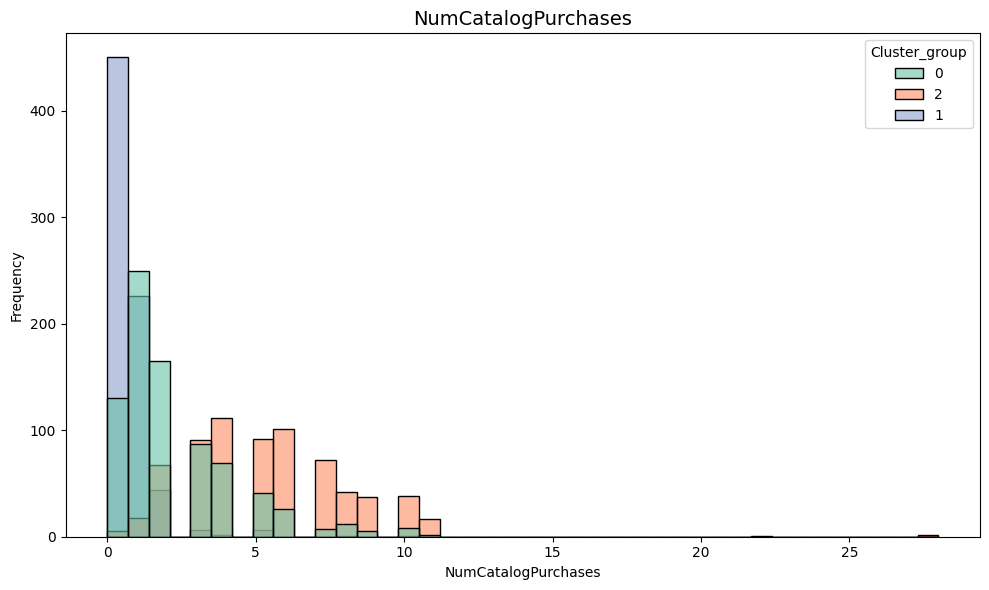

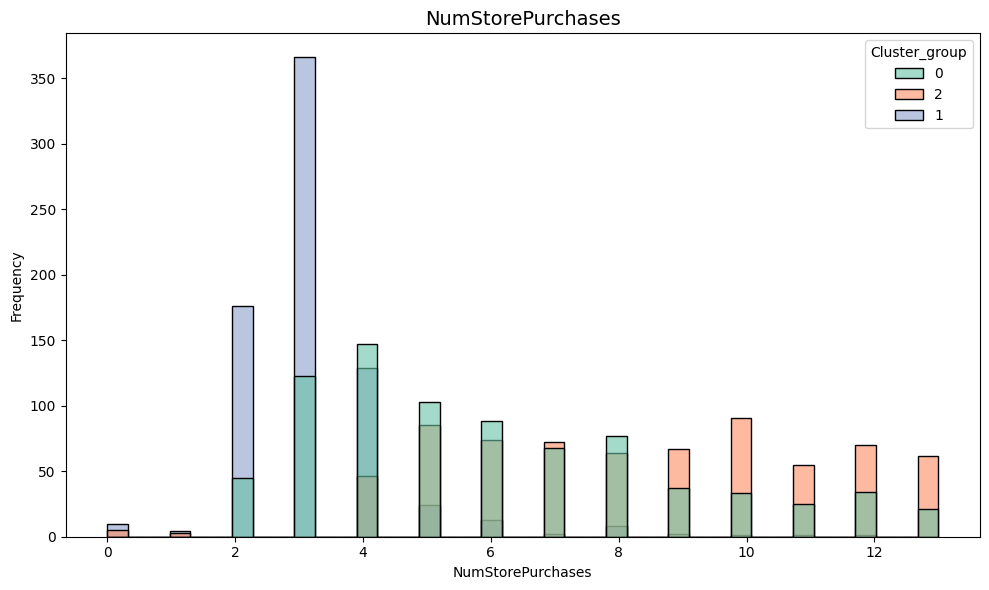

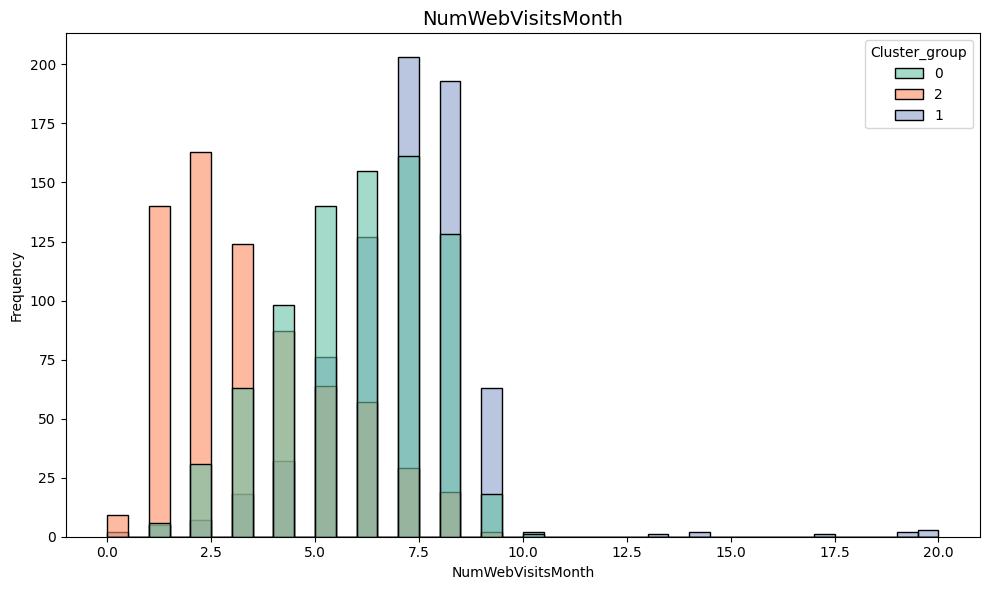

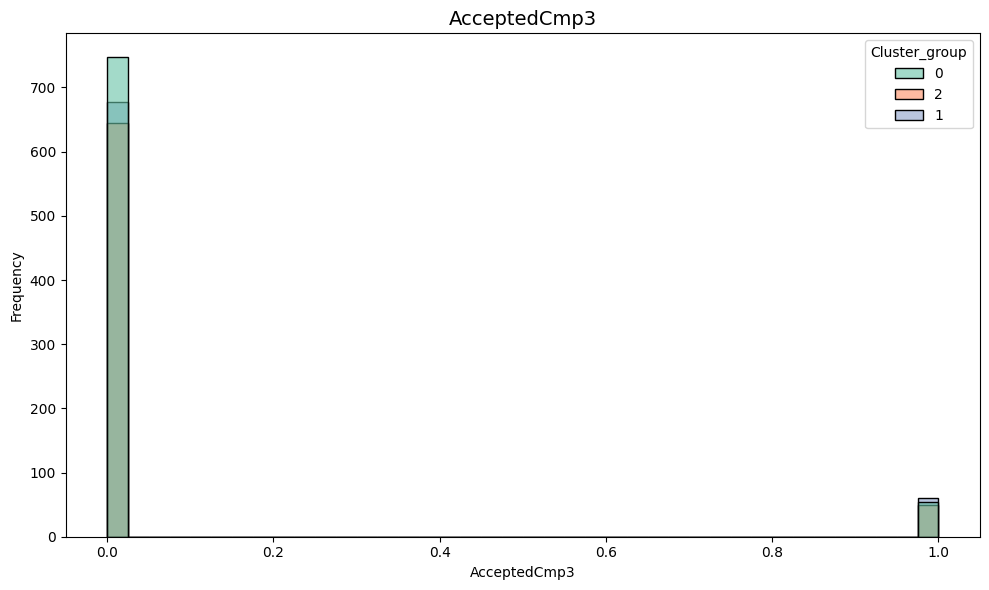

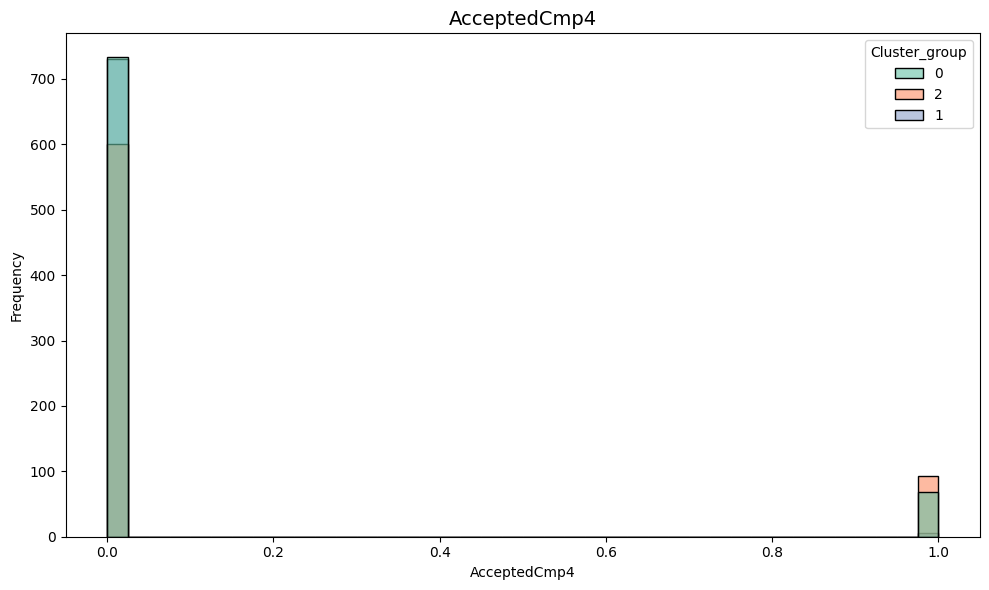

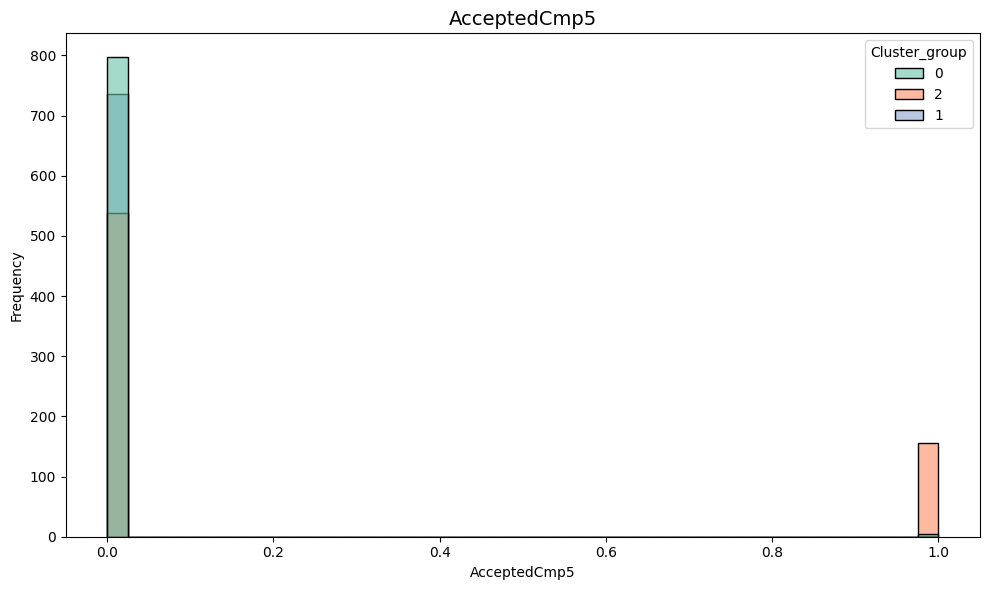

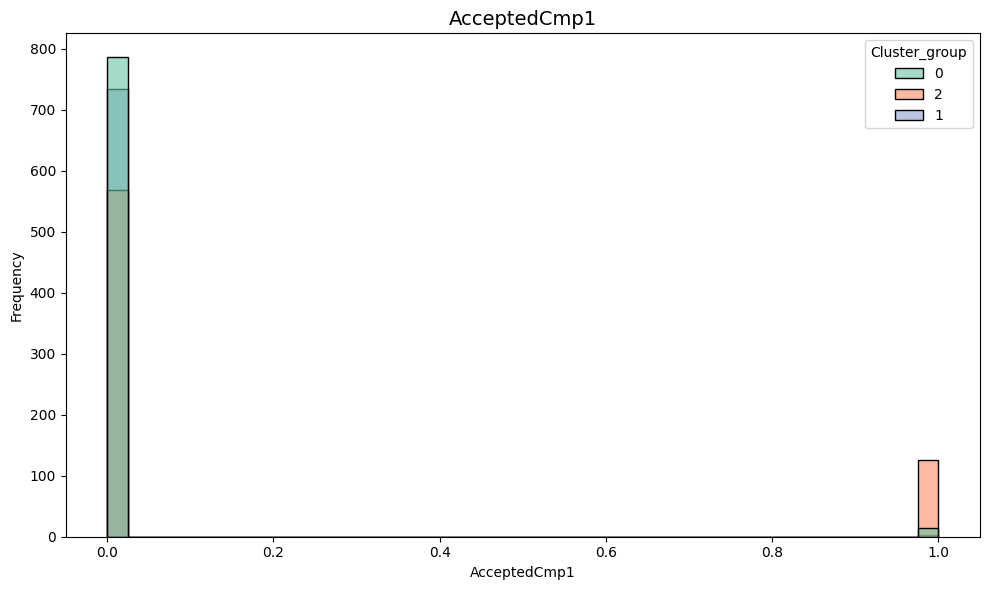

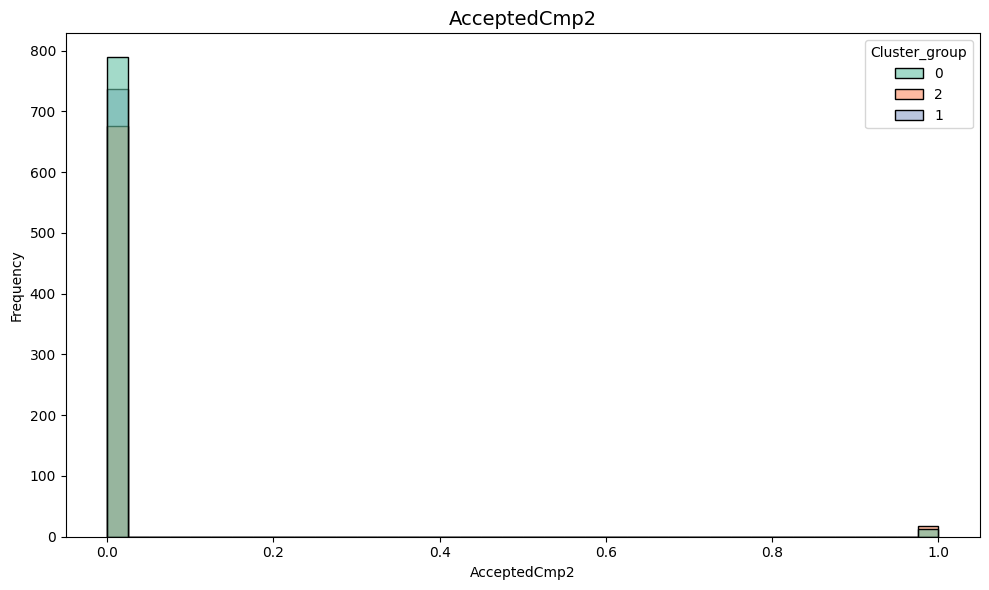

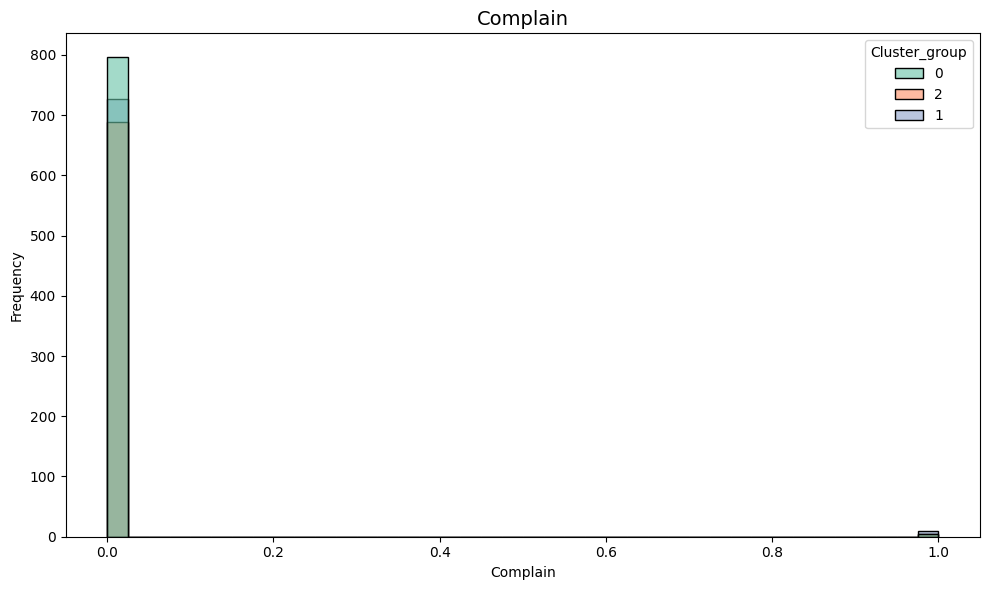

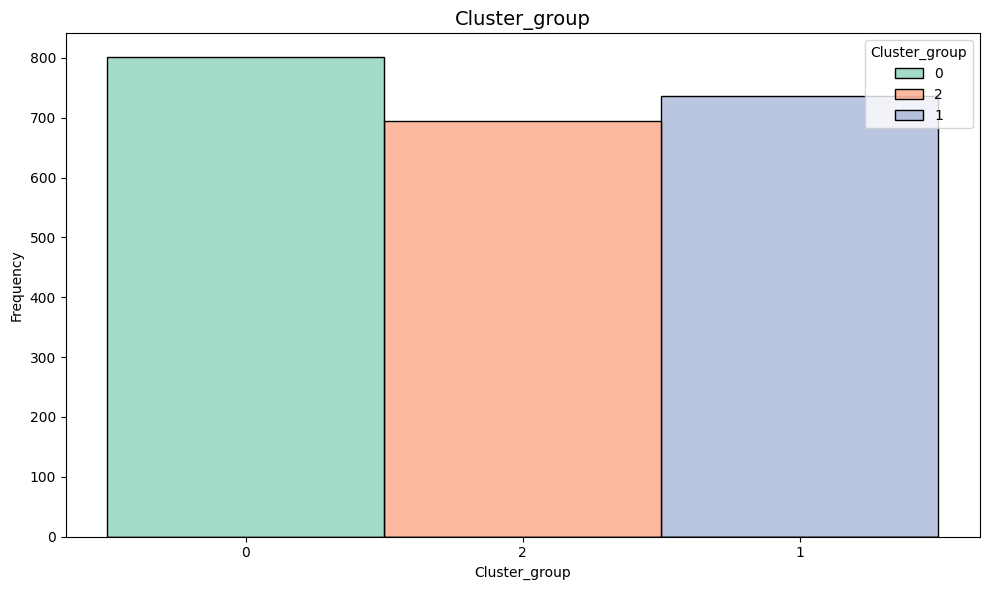

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
df['Cluster_group'] = df['Cluster_group'].astype(str)

for col in df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(
        data=df,
        x=col,
        hue='Cluster_group',         
        multiple='layer',      
        palette='Set2',
        bins=40,
        alpha=0.6,
        legend=True
    )
    plt.title(f'{col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

In [40]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Cluster_group
0,5524,1957,1,1,58138.0,0,0,2012-04-09,58,635,...,10,4,7,0,0,0,0,0,0,0
1,2174,1954,1,1,46344.0,1,1,2014-08-03,38,11,...,1,2,5,0,0,0,0,0,0,0
2,4141,1965,1,0,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,0,0,0,0,2
3,6182,1984,1,0,26646.0,1,0,2014-10-02,26,11,...,0,4,6,0,0,0,0,0,0,1
4,5324,1981,4,0,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2227,10870,1967,1,0,61223.0,0,1,2013-06-13,46,709,...,3,4,5,0,0,0,0,0,0,0
2228,4001,1946,4,0,64014.0,2,1,2014-10-06,56,406,...,2,5,7,0,0,0,1,0,0,0
2229,7270,1981,1,1,56981.0,0,0,2014-01-25,91,908,...,3,13,6,0,1,0,0,0,0,0
2230,8235,1956,2,0,69245.0,0,1,2014-01-24,8,428,...,5,10,3,0,0,0,0,0,0,2


In [43]:
df_only_have_ID_and_Group = df[["ID", "Cluster_group"]]
df_only_have_ID_and_Group


,ID,Cluster_group
0,5524,0
1,2174,0
2,4141,2
3,6182,1
4,5324,0
...,...,...
2227,10870,0
2228,4001,0
2229,7270,0
2230,8235,2


In [44]:
df_only_have_ID_and_Group.to_excel("ID_Group_result.xlsx", index=False)